In [3]:
import numpy as np
import xarray as xr
import xrft
import matplotlib.pyplot as plt
import qgtoolbox as qg
from IPython.display import clear_output
from time import sleep

dm = qg.DataManager(root_dir='..')

In [4]:
experiment = "qg-model"
path = dm.make_experiment(experiment)
sim_path = path / f"{experiment}.nc"

In [5]:
n_epoch = 8
# ds = qg.load_simulation(sim_path, n_epoch)
# ds = qg.load_dataset(sim_path)
epoch_path = path / f"{experiment}_{n_epoch}e.nc"
ds = qg.load_dataset(epoch_path)

config = qg.parse_yaml(dm.config / f"{experiment}.yaml")

w = ds['u'] + 1j*ds['v']
w.attrs['long_name'] = 'absolute velocity'
ds['w'] = w
power_w = xrft.isotropic_power_spectrum(
    ds['w'], dim=['x', 'y'], nfactor=4, truncate=True
)
config

/home/alice/miniconda3/envs/ocean/lib/python3.11/site-packages/xrft/xrft.py:455: FutureWarning: dropping variables using `drop` is deprecated; use drop_vars.
  daft = daft.drop([d for d in dim if d in daft.coords])


{'architecture': {'n_threads': 1},
 'grid': {'n_grid': 256},
 'model': {'rek': 0.01,
  'cnu': 1e-05,
  'af': 1.0,
  'kf': 16.0,
  'dkf': 2.0,
  'beta': 0.0},
 'simulation': {'dt': 0.01, 't_epoch': 100.0},
 'logging': {'log_level': 3, 'twrite': 1.0}}

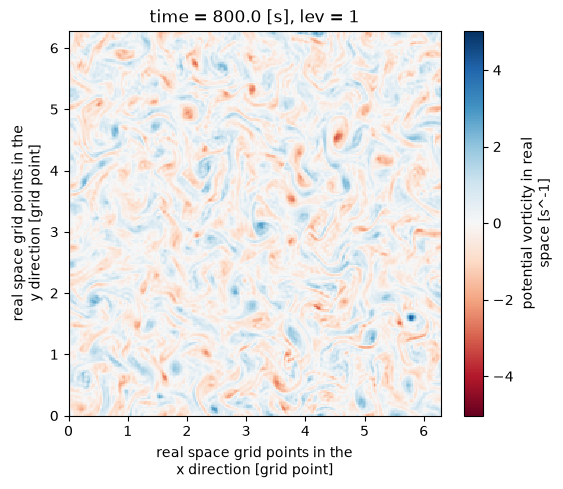

In [6]:
n_frames = len(ds.time)
FPS = 120
Amp = float(np.abs(ds.q).max())
for k in range(n_frames):
    clear_output(wait=True)
    fig, ax = plt.subplots(figsize=(6,5))
    ds.q.isel(time=k).plot(ax=ax, cmap='RdBu', add_colorbar=True, vmin=-Amp, vmax=Amp)
    plt.show()
    sleep(1/FPS)

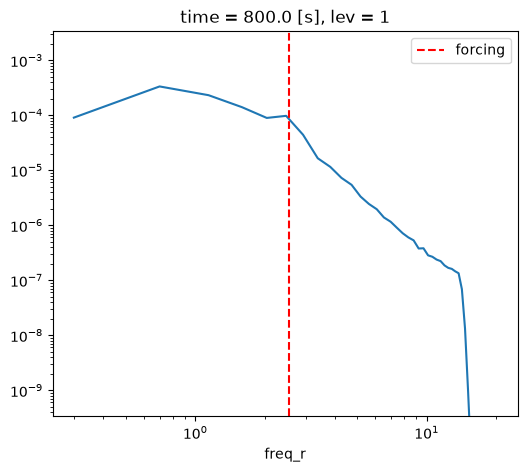

In [7]:
FPS = 120
n_frames = len(ds.time)
Amp = float(np.abs(power_w).max())
for k in range(n_frames):
    clear_output(wait=True)
    fig, ax = plt.subplots(figsize=(6,5))
    power_w.isel(time=k).plot(ax=ax)
    ax.loglog()
    ax.axvline(config['model']['kf']/(2*np.pi), color='red', linestyle='--', label='forcing')
    ax.set_ylim(1e-6 * Amp, 1e1 * Amp)
    plt.legend()
    plt.show()
    sleep(1/FPS)

In [ ]:
power_spec = xrft.power_spectrum(ds['q'], dim=['x', 'y'], real_dim='x')
iso_power_spec.isel(time=-1).plot()


In [ ]:
ds.q.isel(time=-1).plot(cmap='viridis')
plt.show()